In [ ]:
##%pip install statsmodels
##%pip install scikit-learn
##%pip install matplotlib

In [ ]:
import sys
sys.path.append("C:/Users/Powan/Desktop/Maestria/TFM/edev_models/modelos")

import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:

from construir_dataset_maestro import (
        construir_espina_horaria, construir_dataset_diario, dividir_train_val_test,
    )

espina = construir_espina_horaria()          # para EDA/correlaciones
dataset = construir_dataset_diario()          # para modelado
train, val, test = dividir_train_val_test(dataset)

C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:149: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=params)
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:149: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=params)
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:149: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=

In [3]:
print(dataset.columns.tolist())

['price_h00', 'price_h01', 'price_h02', 'price_h03', 'price_h04', 'price_h05', 'price_h06', 'price_h07', 'price_h08', 'price_h09', 'price_h10', 'price_h11', 'price_h12', 'price_h13', 'price_h14', 'price_h15', 'price_h16', 'price_h17', 'price_h18', 'price_h19', 'price_h20', 'price_h21', 'price_h22', 'price_h23', 'demanda_prev_mw_mean', 'demanda_prev_mw_min', 'demanda_prev_mw_max', 'demanda_mercado_prev_mw_mean', 'demanda_mercado_prev_mw_min', 'demanda_mercado_prev_mw_max', 'gen_wind_prev_mw_mean', 'gen_wind_prev_mw_min', 'gen_wind_prev_mw_max', 'gen_solar_pv_prev_mw_mean', 'gen_solar_pv_prev_mw_min', 'gen_solar_pv_prev_mw_max', 'gen_renovables_prev_mw_mean', 'gen_renovables_prev_mw_min', 'gen_renovables_prev_mw_max', 'gen_solartermica_prev_mw_mean', 'gen_solartermica_prev_mw_min', 'gen_solartermica_prev_mw_max', 'cap_baleares_prev_mw_mean', 'cap_baleares_prev_mw_min', 'cap_baleares_prev_mw_max', 'ntc_fr_imp_prev_mw_mean', 'ntc_fr_imp_prev_mw_min', 'ntc_fr_imp_prev_mw_max', 'ntc_fr_exp_p

# Preparacion de datos
Para esta idea inicial el target va a ser la media de todas las horas.
Para esto se va a crear una columna nueva, y se van a elimnar las horas del dataset a utilizar

In [21]:
price_cols = [c for c in train.columns if c.startswith("price_h")]
train["price_mean_d1"] = train[price_cols].mean(axis=1)
feature_cols = [c for c in dataset.columns if c not in price_cols + ["price_mean_d1"]]

In [23]:
train.head(5)

,price_h00,price_h01,price_h02,price_h03,price_h04,price_h05,price_h06,price_h07,price_h08,price_h09,...,tcc_mean_mean,tcc_mean_min,tcc_mean_max,tp_mean_mean,tp_mean_min,tp_mean_max,msl_mean_mean,msl_mean_min,msl_mean_max,price_mean_d1
fecha,,,,,,,,,,,,,,,,,,,,,
2020-01-01,35.40,31.98,30.50,28.79,28.42,28.75,34.16,42.07,44.89,45.26,...,0.495903,0.363025,0.625135,0.002738,0.000735,0.004091,103074.600586,102970.007812,103155.734375,39.995000
2020-01-02,32.05,30.75,29.97,29.80,29.74,29.87,31.21,36.73,42.90,46.00,...,0.712838,0.559886,0.789571,0.012229,0.006811,0.025785,103211.889648,103101.570312,103342.953125,39.506250
2020-01-03,38.01,32.05,31.00,30.20,29.85,29.84,30.10,30.75,31.83,36.67,...,0.449981,0.252931,0.556903,0.006944,0.002459,0.012318,103327.335938,103185.671875,103456.015625,35.670833
2020-01-04,33.10,32.28,31.18,30.10,29.96,29.88,30.38,31.15,32.09,34.27,...,0.182505,0.044597,0.321709,0.001852,0.000100,0.002764,102991.521484,102752.898438,103209.937500,38.175417
2020-01-05,47.85,41.48,34.00,31.92,31.75,31.50,33.18,43.13,44.52,44.96,...,0.231798,0.151852,0.298760,0.000904,0.000484,0.001840,102909.900391,102802.601562,103069.625000,42.166250


In [28]:
feature_cols

['demanda_prev_mw_mean',
 'demanda_prev_mw_min',
 'demanda_prev_mw_max',
 'demanda_mercado_prev_mw_mean',
 'demanda_mercado_prev_mw_min',
 'demanda_mercado_prev_mw_max',
 'gen_wind_prev_mw_mean',
 'gen_wind_prev_mw_min',
 'gen_wind_prev_mw_max',
 'gen_solar_pv_prev_mw_mean',
 'gen_solar_pv_prev_mw_min',
 'gen_solar_pv_prev_mw_max',
 'gen_renovables_prev_mw_mean',
 'gen_renovables_prev_mw_min',
 'gen_renovables_prev_mw_max',
 'gen_solartermica_prev_mw_mean',
 'gen_solartermica_prev_mw_min',
 'gen_solartermica_prev_mw_max',
 'cap_baleares_prev_mw_mean',
 'cap_baleares_prev_mw_min',
 'cap_baleares_prev_mw_max',
 'ntc_fr_imp_prev_mw_mean',
 'ntc_fr_imp_prev_mw_min',
 'ntc_fr_imp_prev_mw_max',
 'ntc_fr_exp_prev_mw_mean',
 'ntc_fr_exp_prev_mw_min',
 'ntc_fr_exp_prev_mw_max',
 'ntc_pt_imp_prev_mw_mean',
 'ntc_pt_imp_prev_mw_min',
 'ntc_pt_imp_prev_mw_max',
 'ntc_pt_exp_prev_mw_mean',
 'ntc_pt_exp_prev_mw_min',
 'ntc_pt_exp_prev_mw_max',
 'ntc_ma_imp_prev_mw_mean',
 'ntc_ma_imp_prev_mw_min',
 

# Feature selection
Spearman

In [5]:
from scipy.stats import spearmanr

In [29]:
def preparar_chunk_train_test(
    dataset: pd.DataFrame,
    fecha_inicio: str = None,
    fecha_fin: str = None,
    test_size: float = 0.2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Selects a date-range chunk of `dataset` and splits it chronologically:
    train = earliest (1 - test_size) of the chunk, test = the most recent
    test_size fraction. Never shuffles.

    fecha_inicio / fecha_fin: 'YYYY-MM-DD' strings, or None to use the
    full available range on that side.
    """
    df = dataset.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if fecha_inicio is not None:
        df = df[df.index >= pd.Timestamp(fecha_inicio)]
    if fecha_fin is not None:
        df = df[df.index <= pd.Timestamp(fecha_fin)]

    n_test = int(len(df) * test_size)
    if n_test == 0 or n_test == len(df):
        raise ValueError(f"test_size={test_size} leaves an empty split for {len(df)} rows")

    train = df.iloc[:-n_test]
    test = df.iloc[-n_test:]
    return train, test

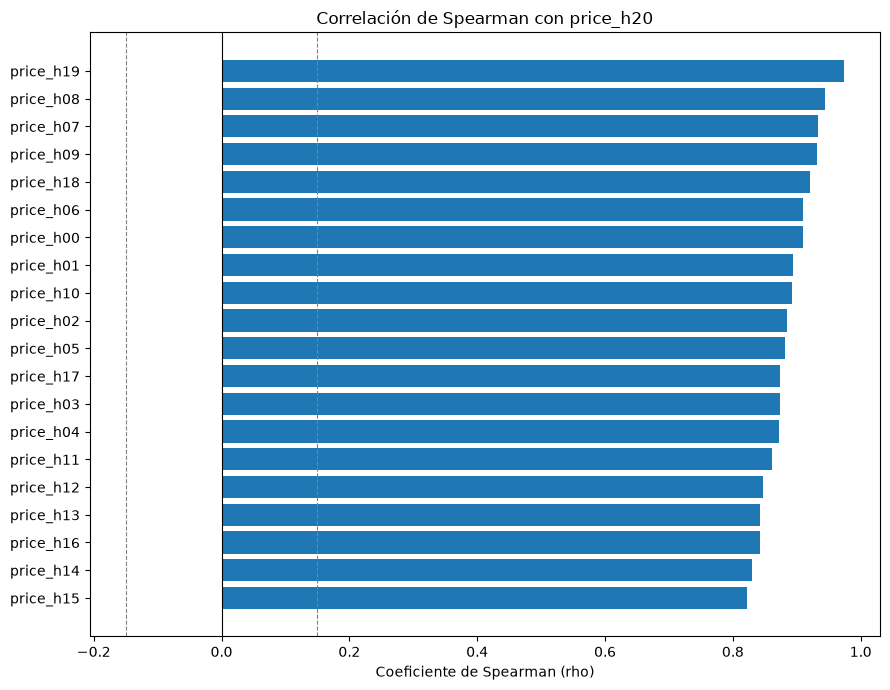

In [18]:
top = RES_df.head(TOP_N).sort_values("spearman_rho")
colors = ["#d62728" if v < 0 else "#1f77b4" for v in top["spearman_rho"]]
 
plt.figure(figsize=(9, max(4, 0.35 * TOP_N)))
plt.barh(top["feature"], top["spearman_rho"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(CORR_THRESHOLD, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(-CORR_THRESHOLD, color="gray", linestyle="--", linewidth=0.8)
plt.title(f"Correlación de Spearman con {target}")
plt.xlabel("Coeficiente de Spearman (rho)")
plt.tight_layout()

plt.show()
plt.close()